# 🧠 Introduction to Small Language Models (SLMs)

**Session Overview:**
This notebook covers the foundations and hands-on practice with Small Language Models (SLMs). By the end of this session, you will:
- Understand what SLMs are and how they differ from LLMs
- Know key SLM architectures: TinyLlama, SmolLM, and Qwen2.5
- Load and run inference using HuggingFace Transformers
- Benchmark 3 SLMs — TinyLlama-1.1B, SmolLM-1.7B, Qwen2.5-1.5B — across quality, throughput, and memory
- Go beyond text-only chat SLMs: run a **multimodal** (vision+language), a **text-to-speech**, and a **code-specific** small model (Part 8)

---
**Runtime Recommendation:** GPU (T4 or better) → `Runtime > Change runtime type > T4 GPU`

## 📦 Part 0: Environment Setup

Install all required libraries. Run this once at the start of your session.

In [1]:
import sys
import os

# Dynamic environment check
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    WORKSHOP_DIR = "/content/drive/MyDrive/SLM Workshop"
else:
    # Use a local folder at the parent level of the notebook directory
    WORKSHOP_DIR = os.path.abspath("../SLM_Workshop")

if not os.path.exists(WORKSHOP_DIR):
    os.makedirs(WORKSHOP_DIR)
    print(f"📁 Created: {WORKSHOP_DIR}")
else:
    print(f"✅ Already exists: {WORKSHOP_DIR}")


✅ Already exists: /Users/sudhanshusingh/Projects/DHS-SLM-Workshop/SLM_Workshop


In [1]:
# Install dependencies
!pip install -q transformers accelerate bitsandbytes sentencepiece protobuf
!pip install -q datasets psutil gputil tabulate

print("✅ All packages installed!")

pyenv: version `3.13' is not installed (set by /Users/sudhanshusingh/Projects/DHS-SLM-Workshop/.python-version)
pyenv: pip: command not found

The `pip' command exists in these Python versions:
  3.12.13
  3.14.4
  miniforge3-26.3.2-0

Note: See 'pyenv help global' for tips on allowing multiple
      Python versions to be found at the same time.
pyenv: version `3.13' is not installed (set by /Users/sudhanshusingh/Projects/DHS-SLM-Workshop/.python-version)
pyenv: pip: command not found

The `pip' command exists in these Python versions:
  3.12.13
  3.14.4
  miniforge3-26.3.2-0

Note: See 'pyenv help global' for tips on allowing multiple
      Python versions to be found at the same time.
✅ All packages installed!


In [2]:
# Standard imports
import time
import psutil
import torch
import warnings
warnings.filterwarnings('ignore')

from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from tabulate import tabulate

# Check GPU availability (CUDA, MPS, or CPU)
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"🖥️  Device: {device}")

if device == "cuda":
    gpu = torch.cuda.get_device_properties(0)
    print(f"🎮 GPU: {gpu.name}")
    print(f"💾 VRAM: {gpu.total_memory / 1e9:.1f} GB")
elif device == "mps":
    print("🎮 GPU: Apple Silicon (MPS)")
else:
    print("⚠️  No GPU found. Some cells will be slow — consider enabling GPU runtime.")


🖥️  Device: mps
🎮 GPU: Apple Silicon (MPS)


---
## 📖 Part 1: What Are Small Language Models?

### 1.1 The SLM Landscape

| Model | Params | Developer | Key Strength |
|---|---|---|---|
| **TinyLlama-1.1B** | 1.1B | Zhang et al. | Ultra-lightweight, fast |
| **SmolLM-1.7B** | 1.7B | HuggingFace | Distilled, on-device ready |
| **Qwen2.5-1.5B** | 1.5B | Alibaba | Strong instruction-following at size |

> 💡 **Beyond general-purpose chat SLMs:** the small-model ecosystem also includes specialized variants — **multimodal** (vision+language), **speech** (TTS), and **code-specific** models. We benchmark 3 general-purpose SLMs above, then try one of each specialized type in **Part 8**.

**Key Design Philosophies:**
- **Extended training** (TinyLlama): Train longer on more tokens despite small size
- **Distillation** (SmolLM): Smaller models trained from larger teacher models
- **Instruction-tuning at scale** (Qwen2.5): Large-scale alignment data drives strong instruction-following relative to parameter count

### 1.2 SLM vs LLM Trade-off Summary

| Dimension | SLM (1–2B) | LLM (70B+) |
|---|---|---|
| Latency | ⚡ Fast (ms–s) | 🐢 Slow (s–mins) |
| Cost | 💚 Very low | 🔴 High |
| Accuracy (general) | 🟡 Moderate | 🟢 High |
| On-device deployment | ✅ Yes | ❌ No |
| Context window | 🟡 2K–32K tokens | 🟢 32K–200K tokens |
| Fine-tuning cost | 💚 Cheap | 🔴 Expensive |


### 1.3 Tokenization & Context Window — A Quick Look

Tokenization converts text into integer IDs. Context window limits how much text a model can "see" at once. Let's explore this concretely.

In [4]:
# Load a lightweight tokenizer to explore tokenization
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")

sample_text = "Small Language Models are efficient neural networks designed for edge and resource-constrained environments."

tokens = tokenizer.encode(sample_text)
decoded_tokens = [tokenizer.decode([t]) for t in tokens]

print(f"📝 Original text ({len(sample_text)} chars):")
print(f"   {sample_text}\n")
print(f"🔢 Token IDs ({len(tokens)} tokens):")
print(f"   {tokens}\n")
print(f"🧩 Token breakdown:")
for i, (tid, tok) in enumerate(zip(tokens, decoded_tokens)):
    print(f"   [{i:2d}] ID={tid:6d}  →  '{tok}'")

📝 Original text (108 chars):
   Small Language Models are efficient neural networks designed for edge and resource-constrained environments.

🔢 Token IDs (19 tokens):
   [1, 18285, 17088, 3382, 1379, 526, 8543, 19677, 14379, 8688, 363, 7636, 322, 6503, 29899, 3075, 22042, 23136, 29889]

🧩 Token breakdown:
   [ 0] ID=     1  →  '<s>'
   [ 1] ID= 18285  →  'Small'
   [ 2] ID= 17088  →  'Language'
   [ 3] ID=  3382  →  'Mod'
   [ 4] ID=  1379  →  'els'
   [ 5] ID=   526  →  'are'
   [ 6] ID=  8543  →  'efficient'
   [ 7] ID= 19677  →  'neural'
   [ 8] ID= 14379  →  'networks'
   [ 9] ID=  8688  →  'designed'
   [10] ID=   363  →  'for'
   [11] ID=  7636  →  'edge'
   [12] ID=   322  →  'and'
   [13] ID=  6503  →  'resource'
   [14] ID= 29899  →  '-'
   [15] ID=  3075  →  'const'
   [16] ID= 22042  →  'rained'
   [17] ID= 23136  →  'environments'
   [18] ID= 29889  →  '.'


In [5]:
# Context window: what happens when you exceed the limit?
model_context_windows = {
    "TinyLlama-1.1B": 2048,
    "SmolLM-1.7B": 2048,
    "Qwen2.5-1.5B": 32768,
}

# Estimate token count for common document types
document_sizes = {
    "Tweet": 30,
    "Email": 200,
    "News article": 800,
    "Short report (5 pages)": 2500,
    "Research paper (20 pages)": 10000,
}

print("📊 Context Window Fit Analysis")
print("=" * 65)
header = ["Document Type", "~Tokens"] + list(model_context_windows.keys())
rows = []
for doc, size in document_sizes.items():
    fits = ["✅" if size <= ctx else "❌" for ctx in model_context_windows.values()]
    rows.append([doc, size] + fits)

print(tabulate(rows, headers=header, tablefmt="grid"))


📊 Context Window Fit Analysis
+---------------------------+-----------+------------------+---------------+----------------+
| Document Type             |   ~Tokens | TinyLlama-1.1B   | SmolLM-1.7B   | Qwen2.5-1.5B   |
+===========================+===========+==================+===============+================+
| Tweet                     |        30 | ✅               | ✅            | ✅             |
+---------------------------+-----------+------------------+---------------+----------------+
| Email                     |       200 | ✅               | ✅            | ✅             |
+---------------------------+-----------+------------------+---------------+----------------+
| News article              |       800 | ✅               | ✅            | ✅             |
+---------------------------+-----------+------------------+---------------+----------------+
| Short report (5 pages)    |      2500 | ❌               | ❌            | ✅             |
+---------------------------+-----------+-

---
## 🤖 Part 2: Understanding Model Architecture & Performance

In this section, we explore how different SLMs are structured and how they perform on real tasks.

> **Note:** We'll use the benchmark models from Part 3 to evaluate their capabilities.

### 2.1 Model Comparison Approach

### 2.2 Benchmark Framework

---
## 🏁 Part 3: Benchmarking Multiple SLMs

We'll now compare multiple SLMs on the **same prompts**, measuring:
- ✍️ Output quality (subjective review)
- ⚡ Token throughput (tokens/second)
- 💾 GPU memory usage (GB)
- ⏱️ Total latency (seconds)

> **Note:** This benchmark runs exactly 3 models — **TinyLlama-1.1B-Chat**, **SmolLM-1.7B-Instruct**, and **Qwen2.5-1.5B-Instruct** — chosen for free-tier Colab (T4) compatibility and to keep load/unload cycles fast within a single session.

In [6]:
# Benchmark configuration
BENCHMARK_MODELS = [
  "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
  "HuggingFaceTB/SmolLM-1.7B-Instruct",
  "Qwen/Qwen2.5-1.5B-Instruct"
]

BENCHMARK_PROMPTS = [
    {
        "name": "Factual Q&A",
        "prompt": "What is the difference between a transformer and an RNN in neural networks? Explain in 3 sentences."
    },
    {
        "name": "Code Generation",
        "prompt": "Write a Python function that checks if a string is a palindrome. Include a docstring and one example."
    },
    {
        "name": "Creative Writing",
        "prompt": "Write a 3-sentence story about a robot that learns to paint."
    },
]

print(f"📋 Benchmark setup:")
print(f"   Models  : {len(BENCHMARK_MODELS)}")
print(f"   Prompts : {len(BENCHMARK_PROMPTS)}")
print(f"   Total runs: {len(BENCHMARK_MODELS) * len(BENCHMARK_PROMPTS)}")

📋 Benchmark setup:
   Models  : 3
   Prompts : 3
   Total runs: 9


In [7]:
def get_gpu_memory_gb():
    """Return current GPU memory usage in GB."""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1e9
    elif torch.backends.mps.is_available():
        return torch.mps.current_allocated_memory() / 1e9
    return 0.0

def run_benchmark(model_name, prompts, max_new_tokens=150):
    """
    Load a model, run all prompts, collect metrics, then unload.
    Returns list of result dicts.
    """
    print(f"\n{'='*65}")
    print(f"🔧 Loading: {model_name}")
    print(f"{'='*65}")

    # Ensure model is downloaded and show progress bar
    from huggingface_hub import snapshot_download
    print(f"📥 Checking/downloading model files...")
    snapshot_download(repo_id=model_name)

    # Free memory from previous model
    if device == "cuda":
        torch.cuda.empty_cache()
    elif device == "mps":
        torch.mps.empty_cache()

    mem_before = get_gpu_memory_gb()

    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16 if device in ["cuda", "mps"] else torch.float32,
        device_map="auto" if device == "cuda" else None,
        trust_remote_code=True,
    )
    if device == "mps":
        model = model.to(device)

    mem_after = get_gpu_memory_gb()
    model_mem = mem_after - mem_before
    print(f"💾 Model memory footprint: {model_mem:.2f} GB")

    results = []
    for p in prompts:
        print(f"\n  ▶ Running: [{p['name']}]")
        inputs = tokenizer(p["prompt"], return_tensors="pt").to(model.device)
        input_len = inputs["input_ids"].shape[1]

        start = time.time()
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=0.7,
                pad_token_id=tokenizer.eos_token_id,
            )
        elapsed = time.time() - start

        new_tokens = outputs[0][input_len:]
        response = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
        throughput = len(new_tokens) / elapsed

        results.append({
            "model": model_name.split("/")[-1],
            "task": p["name"],
            "latency_s": round(elapsed, 2),
            "tokens_generated": len(new_tokens),
            "throughput_tps": round(throughput, 1),
            "memory_gb": round(model_mem, 2),
            "response": response,
        })
        print(f"     ✅ Done — {elapsed:.2f}s | {throughput:.1f} tok/s")

    # Unload model to free memory
    del model
    if device == "cuda":
        torch.cuda.empty_cache()
    elif device == "mps":
        torch.mps.empty_cache()
    print(f"\n🗑️  Model unloaded, memory freed.")

    return results

print("✅ Benchmark function ready.")

✅ Benchmark function ready.


In [8]:
# ⚠️ This cell runs the full benchmark — may take 5-10 minutes
all_results = []

for model_name in BENCHMARK_MODELS:
    results = run_benchmark(model_name, BENCHMARK_PROMPTS)
    all_results.extend(results)

print(f"\n🏁 Benchmark complete! Total runs: {len(all_results)}")


🔧 Loading: TinyLlama/TinyLlama-1.1B-Chat-v1.0
📥 Checking/downloading model files...


Fetching 10 files: 100%|██████████| 10/10 [00:00<00:00, 2423.05it/s]
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2026.99it/s]


💾 Model memory footprint: 2.20 GB

  ▶ Running: [Factual Q&A]


[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


     ✅ Done — 1.23s | 0.8 tok/s

  ▶ Running: [Code Generation]


...

     ✅ Done — 4.54s | 33.1 tok/s

  ▶ Running: [Creative Writing]
     ✅ Done — 0.10s | 10.2 tok/s

🗑️  Model unloaded, memory freed.

🔧 Loading: HuggingFaceTB/SmolLM-1.7B-Instruct
📥 Checking/downloading model files...


Loading weights: 100%|██████████| 218/218 [00:02<00:00, 101.82it/s]


💾 Model memory footprint: 3.42 GB

  ▶ Running: [Factual Q&A]
     ✅ Done — 0.18s | 5.7 tok/s

  ▶ Running: [Code Generation]
     ✅ Done — 2.57s | 21.0 tok/s

  ▶ Running: [Creative Writing]
     ✅ Done — 0.19s | 5.3 tok/s

🗑️  Model unloaded, memory freed.

🔧 Loading: Qwen/Qwen2.5-1.5B-Instruct
📥 Checking/downloading model files...


Loading weights: 100%|██████████| 338/338 [00:00<00:00, 848.99it/s] 


💾 Model memory footprint: 3.09 GB

  ▶ Running: [Factual Q&A]
     ✅ Done — 5.51s | 18.5 tok/s

  ▶ Running: [Code Generation]
     ✅ Done — 6.52s | 23.0 tok/s

  ▶ Running: [Creative Writing]
     ✅ Done — 3.27s | 22.3 tok/s

🗑️  Model unloaded, memory freed.

🏁 Benchmark complete! Total runs: 9


### 3.1 Benchmark Results: Metrics Table

In [9]:
# Display numeric metrics
print("\n📊 Benchmark Metrics Summary")
print("=" * 80)

headers = ["Model", "Task", "Latency (s)", "Tokens", "Throughput (tok/s)", "Memory (GB)"]
rows = [
    [r["model"], r["task"], r["latency_s"], r["tokens_generated"], r["throughput_tps"], r["memory_gb"]]
    for r in all_results
]
print(tabulate(rows, headers=headers, tablefmt="grid"))


📊 Benchmark Metrics Summary
+--------------------------+------------------+---------------+----------+----------------------+---------------+
| Model                    | Task             |   Latency (s) |   Tokens |   Throughput (tok/s) |   Memory (GB) |
+==========================+==================+===============+==========+======================+===============+
| TinyLlama-1.1B-Chat-v1.0 | Factual Q&A      |          1.23 |        1 |                  0.8 |          2.2  |
+--------------------------+------------------+---------------+----------+----------------------+---------------+
| TinyLlama-1.1B-Chat-v1.0 | Code Generation  |          4.54 |      150 |                 33.1 |          2.2  |
+--------------------------+------------------+---------------+----------+----------------------+---------------+
| TinyLlama-1.1B-Chat-v1.0 | Creative Writing |          0.1  |        1 |                 10.2 |          2.2  |
+--------------------------+------------------+------------

In [10]:
# Per-model aggregate stats
from collections import defaultdict

model_stats = defaultdict(lambda: {"latencies": [], "throughputs": [], "memory": []})
for r in all_results:
    model_stats[r["model"]]["latencies"].append(r["latency_s"])
    model_stats[r["model"]]["throughputs"].append(r["throughput_tps"])
    model_stats[r["model"]]["memory"].append(r["memory_gb"])

print("\n📈 Per-Model Aggregate Performance")
print("=" * 65)
agg_headers = ["Model", "Avg Latency (s)", "Avg Throughput (tok/s)", "Memory (GB)"]
agg_rows = []
for model, stats in model_stats.items():
    agg_rows.append([
        model,
        round(sum(stats["latencies"]) / len(stats["latencies"]), 2),
        round(sum(stats["throughputs"]) / len(stats["throughputs"]), 1),
        stats["memory"][0],  # same across tasks
    ])
print(tabulate(agg_rows, headers=agg_headers, tablefmt="grid"))


📈 Per-Model Aggregate Performance
+--------------------------+-------------------+--------------------------+---------------+
| Model                    |   Avg Latency (s) |   Avg Throughput (tok/s) |   Memory (GB) |
+==========================+===================+==========================+===============+
| TinyLlama-1.1B-Chat-v1.0 |              1.96 |                     14.7 |          2.2  |
+--------------------------+-------------------+--------------------------+---------------+
| SmolLM-1.7B-Instruct     |              0.98 |                     10.7 |          3.42 |
+--------------------------+-------------------+--------------------------+---------------+
| Qwen2.5-1.5B-Instruct    |              5.1  |                     21.3 |          3.09 |
+--------------------------+-------------------+--------------------------+---------------+


### 3.2 Qualitative Output Comparison

In [11]:
# Side-by-side output comparison for each task
tasks = list(set(r["task"] for r in all_results))

for task in tasks:
    print(f"\n{'='*65}")
    print(f"📝 TASK: {task}")
    task_prompt = next(p["prompt"] for p in BENCHMARK_PROMPTS if p["name"] == task)
    print(f"❓ Prompt: {task_prompt[:100]}..." if len(task_prompt) > 100 else f"❓ Prompt: {task_prompt}")
    print(f"{'='*65}")

    task_results = [r for r in all_results if r["task"] == task]
    for r in task_results:
        print(f"\n🤖 [{r['model']}] ({r['throughput_tps']} tok/s, {r['latency_s']}s)")
        print("-" * 60)
        print(r["response"][:500] + ("..." if len(r["response"]) > 500 else ""))

print(f"\n{'='*65}")


📝 TASK: Factual Q&A
❓ Prompt: What is the difference between a transformer and an RNN in neural networks? Explain in 3 sentences.

🤖 [TinyLlama-1.1B-Chat-v1.0] (0.8 tok/s, 1.23s)
------------------------------------------------------------


🤖 [SmolLM-1.7B-Instruct] (5.7 tok/s, 0.18s)
------------------------------------------------------------


🤖 [Qwen2.5-1.5B-Instruct] (18.5 tok/s, 5.51s)
------------------------------------------------------------
Transformers are designed for sequence-to-sequence tasks, whereas Recurrent Neural Networks (RNNs) can handle sequences of varying lengths. Transformers use self-attention mechanisms to process information more efficiently than traditional RNNs, which rely on loops to🍹process sequential data. RNNs TRUE can learn long-term dependencies, but they suffer from vanishing or explodingמטופל gradients, making them less suitable for very long sequences. Transformers do not have this problem, allowing the...

📝 TASK: Creative Writing
❓ Prompt: Wri

---
## 📊 Part 4: Visualization — Benchmark Comparison Charts

Matplotlib is building the font cache; this may take a moment.


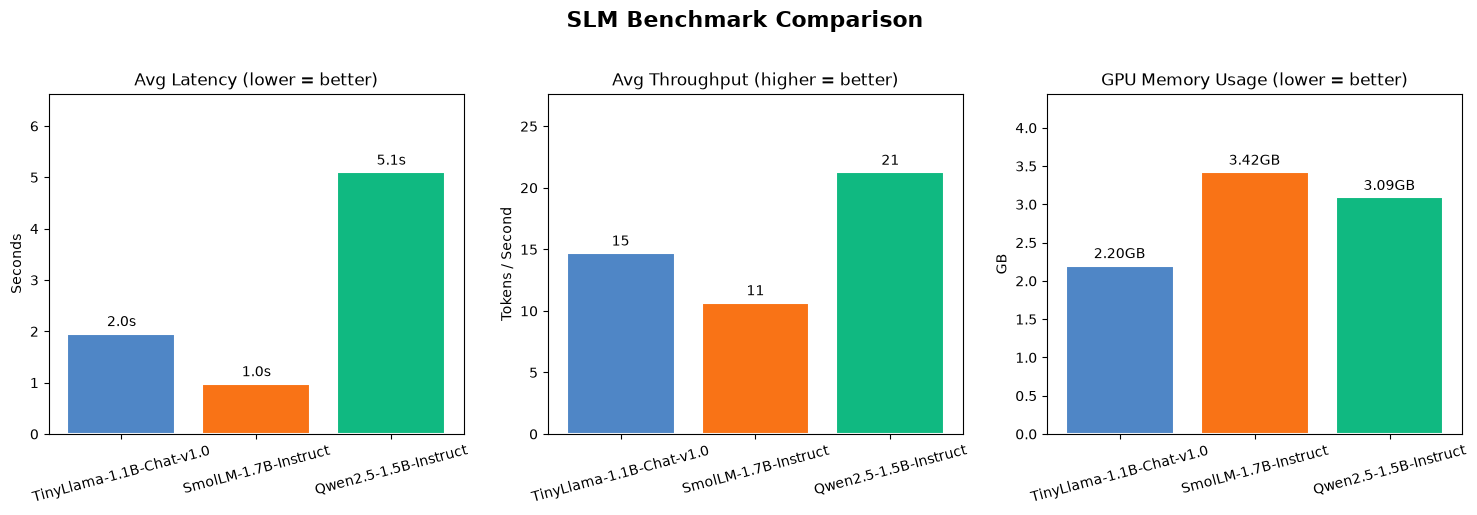

✅ Chart saved as slm_benchmark.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

models = list(model_stats.keys())
avg_latencies = [sum(model_stats[m]["latencies"]) / len(model_stats[m]["latencies"]) for m in models]
avg_throughputs = [sum(model_stats[m]["throughputs"]) / len(model_stats[m]["throughputs"]) for m in models]
memories = [model_stats[m]["memory"][0] for m in models]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("SLM Benchmark Comparison", fontsize=16, fontweight="bold", y=1.02)

colors = ["#4F86C6", "#F97316", "#10B981", "#8B5CF6"]

# Plot 1: Avg Latency
bars = axes[0].bar(models, avg_latencies, color=colors[:len(models)], edgecolor="white", linewidth=1.5)
axes[0].set_title("Avg Latency (lower = better)", fontsize=12)
axes[0].set_ylabel("Seconds")
axes[0].bar_label(bars, fmt="%.1fs", padding=3)
axes[0].set_ylim(0, max(avg_latencies) * 1.3)
axes[0].tick_params(axis='x', rotation=15)

# Plot 2: Throughput
bars = axes[1].bar(models, avg_throughputs, color=colors[:len(models)], edgecolor="white", linewidth=1.5)
axes[1].set_title("Avg Throughput (higher = better)", fontsize=12)
axes[1].set_ylabel("Tokens / Second")
axes[1].bar_label(bars, fmt="%.0f", padding=3)
axes[1].set_ylim(0, max(avg_throughputs) * 1.3)
axes[1].tick_params(axis='x', rotation=15)

# Plot 3: Memory
bars = axes[2].bar(models, memories, color=colors[:len(models)], edgecolor="white", linewidth=1.5)
axes[2].set_title("GPU Memory Usage (lower = better)", fontsize=12)
axes[2].set_ylabel("GB")
axes[2].bar_label(bars, fmt="%.2fGB", padding=3)
axes[2].set_ylim(0, max(memories) * 1.3)
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("slm_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved as slm_benchmark.png")

---
## 🏋️ Part 5: Bonus — Try Your Own Prompt!

Now that you've seen the benchmarks, try your own prompts. Modify the cell below and rerun.

In [19]:
# ✏️ EDIT ME: Try any prompt you like!
YOUR_PROMPT = "Explain how a neural network learns to recognize images, in simple terms for a 10 year old."

print(f"❓ Your prompt:\n   {YOUR_PROMPT}\n")

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import time

for model_name in BENCHMARK_MODELS:
    print(f"\n⏳ Loading {model_name}...")
    try:
        # Ensure model is cached/downloaded
        from huggingface_hub import snapshot_download
        snapshot_download(repo_id=model_name)

        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch.float16 if device in ["cuda", "mps"] else torch.float32,
            device_map="auto" if device == "cuda" else None,
        )
        if device == "mps":
            model = model.to(device)

        # Prepare prompt
        inputs = tokenizer(YOUR_PROMPT, return_tensors="pt").to(model.device)

        # Generate response
        start = time.time()
        outputs = model.generate(
            **inputs,
            max_new_tokens=250,
            temperature=0.7,
            top_p=0.9,
            do_sample=True
        )
        elapsed = time.time() - start

        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        n_toks = outputs[0].shape[0] - inputs['input_ids'].shape[1]

        print(f"🤖 {model_name.split('/')[-1]} response:")
        print("-" * 60)
        print(response or ( "❌ Repeats" if reponse == YOUR_PROMPT else "❌ Nothing"))
        print("-" * 60)
        print(f"⏱️  {elapsed:.2f}s | {n_toks} tokens | {n_toks/elapsed:.1f} tok/s")

        # Clean up memory after each model
        del model, tokenizer
        if device == "cuda":
            torch.cuda.empty_cache()
        elif device == "mps":
            torch.mps.empty_cache()

    except Exception as e:
        print(f"❌ Error with model {model_name}: {e}")


❓ Your prompt:
   Explain how a neural network learns to recognize images, in simple terms for a 10 year old.


⏳ Loading TinyLlama/TinyLlama-1.1B-Chat-v1.0...


Loading weights: 100%|██████████| 201/201 [00:01<00:00, 196.61it/s]
[transformers] Both `max_new_tokens` (=250) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🤖 TinyLlama-1.1B-Chat-v1.0 response:
------------------------------------------------------------
Explain how a neural network learns to recognize images, in simple terms for a 10 year old.
------------------------------------------------------------
⏱️  0.08s | 1 tokens | 12.1 tok/s

⏳ Loading HuggingFaceTB/SmolLM-1.7B-Instruct...


Loading weights: 100%|██████████| 218/218 [00:02<00:00, 91.83it/s] 


🤖 SmolLM-1.7B-Instruct response:
------------------------------------------------------------
Explain how a neural network learns to recognize images, in simple terms for a 10 year old.
------------------------------------------------------------
⏱️  0.10s | 1 tokens | 10.0 tok/s

⏳ Loading Qwen/Qwen2.5-1.5B-Instruct...


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 227.65it/s]


🤖 Qwen2.5-1.5B-Instruct response:
------------------------------------------------------------
Explain how a neural network learns to recognize images, in simple terms for a 10 year old. Imagine you have a big book with thousands of pictures of different animals. Each picture is like a puzzle piece that fits into one of many shapes or patterns we've learned about.

Now, the computer (our AI friend) has to figure out which shape each picture belongs to without looking at it directly. To do this:

1. **Start with random guesses:** Just like how you might start guessing what animal is on each page by picking any pattern you see, our computer starts by making guesses based on its knowledge of all the animals and their features discarding some possibilities.

2. **Use connections between neurons:** The brain of the computer (the neural network) works similarly to how your brain does. Neurons are like tiny nerve cells that connect to each other, much like how neurons connect in your body. Wh

---
## 🎯 Part 6: Key Takeaways

| Insight | Details |
|---|---|
| **SLMs ≠ bad** | Well-trained SLMs like Qwen2.5-1.5B can outperform naive baselines on focused tasks |
| **Throughput matters** | Higher tok/s = better UX, especially for streaming applications |
| **Memory is the bottleneck** | Quantization (4-bit) is essential for on-device/edge SLM deployment |
| **Task-model fit** | Always benchmark on *your* tasks — leaderboards ≠ real-world performance |
| **Context window** | SLMs shine on short-to-medium inputs; long docs need chunking strategies |

### 🚀 What's Next?
- **Fine-tuning SLMs**: LoRA/QLoRA on domain-specific data
- **GGUF / llama.cpp**: Run SLMs locally without GPU
- **Retrieval-Augmented Generation (RAG)**: Pair SLMs with knowledge bases
- **Deployment**: Ollama, LM Studio, HuggingFace Inference Endpoints

---
**Resources:**
- [TinyLlama](https://github.com/jzhang38/TinyLlama)
- [SmolLM Blog](https://huggingface.co/blog/smollm)
- [Qwen2.5 Blog](https://qwenlm.github.io/blog/qwen2.5/)
- [HuggingFace Open LLM Leaderboard](https://huggingface.co/spaces/HuggingFaceH4/open_llm_leaderboard)


---
## 🧪 Part 7: MediLearn Shared Evaluation — Establishing the Baseline

This workshop builds one running case study across every module: **MediLearn**, a medical-education
assistant. Starting here, every module (1, 2, 3, 4, and 6) evaluates its model against the **same
60-question medical benchmark**, scored the **same way**. Only the model/pipeline changes between
modules — so when the numbers move, you'll know it's because of what you built, not because the test
changed.

This section:
1. Mounts Google Drive and sets up the shared `SLM Workshop` folder every later module will read from / write to
2. Loads the fixed 60-question evaluation set (6 medical categories × 10 questions, 3 difficulty tiers)
3. Defines the scoring harness (term coverage, semantic relevance, latency) reused identically in every later module
4. Runs it once against `HuggingFaceTB/SmolLM-1.7B-Instruct` — completely **un-fine-tuned** — the exact
   base model Module 2 will fine-tune. This is the "before" picture.

In [20]:
# Install the embedding model used for semantic-relevance scoring.
# This is the same embedding model used in Modules 3, 4, and 6 for consistency.
!pip install -q sentence-transformers
print("✅ sentence-transformers installed")

pyenv: version `3.13' is not installed (set by /Users/sudhanshusingh/Projects/DHS-SLM-Workshop/.python-version)
pyenv: pip: command not found

The `pip' command exists in these Python versions:
  3.12.13
  3.14.4
  miniforge3-26.3.2-0

Note: See 'pyenv help global' for tips on allowing multiple
      Python versions to be found at the same time.
✅ sentence-transformers installed


In [21]:
# Mount Google Drive and set up the shared workshop folder.
# Module 2 will save its merged fine-tuned model here; every later module loads it from this path.
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    WORKSHOP_DIR = "/content/drive/MyDrive/SLM Workshop"
else:
    WORKSHOP_DIR = os.path.abspath("../SLM_Workshop")

EVAL_DIR     = f"{WORKSHOP_DIR}/eval"
RESULTS_DIR  = f"{EVAL_DIR}/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"📁 Shared workshop folder ready at: {WORKSHOP_DIR}")
print(f"   Eval set + results will live under: {EVAL_DIR}")


📁 Shared workshop folder ready at: /Users/sudhanshusingh/Projects/DHS-SLM-Workshop/SLM_Workshop
   Eval set + results will live under: /Users/sudhanshusingh/Projects/DHS-SLM-Workshop/SLM_Workshop/eval


In [22]:
# The fixed 60-question MediLearn evaluation set.
# Embedded directly so this notebook never depends on an upload step — and a canonical
# copy is written to Drive below so Modules 2, 3, 4, and 6 can confirm they're using
# the exact same set.
import json

MEDILEARN_EVAL_JSON = '''[{"id":"Q001","category":"Cardiology","difficulty":"L1","question":"What is the normal resting heart rate range for a healthy adult?","key_terms":["60","100","beats per minute","bpm"],"reference_answer":"A normal resting heart rate for adults is approximately 60-100 beats per minute."},{"id":"Q002","category":"Cardiology","difficulty":"L1","question":"What does the P wave represent on an ECG?","key_terms":["atrial","depolarization","p wave"],"reference_answer":"The P wave represents atrial depolarization, the electrical activation of the atria before they contract."},{"id":"Q003","category":"Cardiology","difficulty":"L1","question":"What do the S1 and S2 heart sounds represent?","key_terms":["mitral","tricuspid","aortic","pulmonic","valve closure"],"reference_answer":"S1 is caused by closure of the mitral and tricuspid valves at the start of systole; S2 is caused by closure of the aortic and pulmonic valves at the start of diastole."},{"id":"Q004","category":"Cardiology","difficulty":"L2","question":"A 58-year-old smoker presents with substernal chest pain radiating to the left arm, diaphoresis, and dyspnea. What is the most likely diagnosis and first-line antiplatelet therapy?","key_terms":["myocardial infarction","mi","acute coronary syndrome","aspirin","clopidogrel","p2y12"],"reference_answer":"This presentation is consistent with acute myocardial infarction (ACS). First-line antiplatelet therapy is aspirin, typically combined with a P2Y12 inhibitor such as clopidogrel."},{"id":"Q005","category":"Cardiology","difficulty":"L2","question":"What ECG finding distinguishes an NSTEMI from a STEMI?","key_terms":["st elevation","st segment","troponin","nstemi","stemi"],"reference_answer":"STEMI shows persistent ST-segment elevation on ECG, while NSTEMI does not show ST elevation but troponin is still elevated, indicating myocardial injury without complete vessel occlusion."},{"id":"Q006","category":"Cardiology","difficulty":"L2","question":"A patient with COPD presents with dyspnea, orthopnea, JVD, and an S3 gallop. What is the likely diagnosis and first-line medication class?","key_terms":["heart failure","diuretic","loop diuretic","fluid overload"],"reference_answer":"These findings suggest decompensated heart failure with volume overload. First-line treatment is a loop diuretic such as furosemide to reduce fluid overload."},{"id":"Q007","category":"Cardiology","difficulty":"L2","question":"What is the recommended blood pressure target for a patient with hypertension and chronic kidney disease per current guidelines?","key_terms":["130","80","mmhg","target"],"reference_answer":"Current guidelines generally recommend a blood pressure target below 130/80 mmHg for patients with hypertension and chronic kidney disease."},{"id":"Q008","category":"Cardiology","difficulty":"L3","question":"A 72-year-old with HFrEF (EF 30%) remains symptomatic despite an ACE inhibitor and beta-blocker. What two additional guideline-directed therapies should be considered, and why?","key_terms":["mineralocorticoid receptor antagonist","mra","sglt2 inhibitor","spironolactone","mortality benefit"],"reference_answer":"Guideline-directed therapy adds a mineralocorticoid receptor antagonist (e.g., spironolactone) and an SGLT2 inhibitor, both of which have demonstrated mortality and hospitalization benefit on top of ACE inhibitor and beta-blocker therapy in HFrEF."},{"id":"Q009","category":"Cardiology","difficulty":"L3","question":"Explain why beta-blockers are avoided in acute decompensated heart failure with cardiogenic shock but used in chronic stable heart failure.","key_terms":["negative inotrope","cardiac output","cardiogenic shock","chronic remodeling"],"reference_answer":"In acute cardiogenic shock, beta-blockers further reduce contractility and cardiac output, worsening hypoperfusion. In chronic stable heart failure, beta-blockers reduce sympathetic overdrive and adverse remodeling over time, improving long-term survival once the patient is hemodynamically stable."},{"id":"Q010","category":"Cardiology","difficulty":"L3","question":"A patient on warfarin presents with an INR of 8 and no active bleeding. What is the appropriate management?","key_terms":["hold warfarin","vitamin k","oral vitamin k","inr"],"reference_answer":"Warfarin should be held, and oral vitamin K should be administered to reduce the INR, since the patient is not actively bleeding and rapid reversal with clotting factors is not required."},{"id":"Q011","category":"Neurology","difficulty":"L1","question":"Which cranial nerves are primarily responsible for eye movement?","key_terms":["cranial nerve iii","oculomotor","trochlear","abducens","cn iv","cn vi"],"reference_answer":"Eye movement is controlled by cranial nerve III (oculomotor), IV (trochlear), and VI (abducens)."},{"id":"Q012","category":"Neurology","difficulty":"L1","question":"What is the primary function of the cerebellum?","key_terms":["coordination","balance","motor","fine motor control"],"reference_answer":"The cerebellum coordinates voluntary movement, balance, and fine motor control."},{"id":"Q013","category":"Neurology","difficulty":"L1","question":"Define aphasia and name its two major types.","key_terms":["aphasia","broca","wernicke","language"],"reference_answer":"Aphasia is an impairment of language production or comprehension. The two major types are Broca's (expressive) aphasia and Wernicke's (receptive) aphasia."},{"id":"Q014","category":"Neurology","difficulty":"L2","question":"A patient presents with sudden facial drooping, arm weakness, and aphasia. What is the diagnostic and treatment window for thrombolysis?","key_terms":["stroke","tpa","thrombolysis","4.5 hours","ct"],"reference_answer":"This presentation suggests acute ischemic stroke. After a non-contrast CT rules out hemorrhage, IV tPA (thrombolysis) can be given within 4.5 hours of symptom onset."},{"id":"Q015","category":"Neurology","difficulty":"L2","question":"What CSF findings differentiate bacterial from viral meningitis?","key_terms":["glucose","protein","neutrophil","lymphocyte","csf"],"reference_answer":"Bacterial meningitis typically shows low glucose, high protein, and neutrophil predominance in CSF, while viral meningitis shows normal glucose, mildly elevated protein, and lymphocyte predominance."},{"id":"Q016","category":"Neurology","difficulty":"L2","question":"A patient with diplopia, ptosis, and symptoms that improve with rest is suspected to have which neuromuscular disorder, and what test confirms it?","key_terms":["myasthenia gravis","acetylcholine receptor antibody","edrophonium","ice pack test"],"reference_answer":"This presentation is consistent with myasthenia gravis. It can be confirmed with acetylcholine receptor antibody testing or the edrophonium (Tensilon) test."},{"id":"Q017","category":"Neurology","difficulty":"L2","question":"What is the first-line treatment for status epilepticus?","key_terms":["benzodiazepine","lorazepam","diazepam","iv"],"reference_answer":"First-line treatment for status epilepticus is an IV benzodiazepine, such as lorazepam or diazepam."},{"id":"Q018","category":"Neurology","difficulty":"L3","question":"A patient presents with ascending symmetric weakness after a recent gastrointestinal infection. What is the diagnosis, expected CSF finding, and key treatment?","key_terms":["guillain-barre","albuminocytologic dissociation","ivig","plasmapheresis"],"reference_answer":"This is consistent with Guillain-Barre syndrome. CSF typically shows albuminocytologic dissociation (elevated protein with normal cell count). Treatment is IVIG or plasmapheresis."},{"id":"Q019","category":"Neurology","difficulty":"L3","question":"A 65-year-old presents with a sudden severe headache described as 'the worst of my life,' with no focal deficits, and a negative CT. What is the next diagnostic step, and what condition must be ruled out?","key_terms":["lumbar puncture","subarachnoid hemorrhage","xanthochromia"],"reference_answer":"The next step is a lumbar puncture to look for xanthochromia, since a sudden severe ('thunderclap') headache raises concern for subarachnoid hemorrhage even with a negative CT."},{"id":"Q020","category":"Neurology","difficulty":"L3","question":"Compare the mechanism and clinical use of IV thrombolysis versus mechanical thrombectomy in acute ischemic stroke, including time windows.","key_terms":["tpa","thrombectomy","4.5 hours","24 hours","large vessel occlusion"],"reference_answer":"IV thrombolysis (tPA) dissolves the clot pharmacologically and is given within 4.5 hours of onset. Mechanical thrombectomy physically removes the clot via catheter and can be used up to 24 hours in select patients with large vessel occlusion, often combined with tPA."},{"id":"Q021","category":"Respiratory","difficulty":"L1","question":"What is the normal respiratory rate range for a resting adult?","key_terms":["12","20","breaths per minute"],"reference_answer":"A normal resting respiratory rate for adults is approximately 12-20 breaths per minute."},{"id":"Q022","category":"Respiratory","difficulty":"L1","question":"What does a low FEV1/FVC ratio indicate, obstructive or restrictive lung disease?","key_terms":["obstructive","fev1","fvc","ratio"],"reference_answer":"A low FEV1/FVC ratio indicates an obstructive pattern, as seen in conditions like asthma and COPD."},{"id":"Q023","category":"Respiratory","difficulty":"L1","question":"What is the most common cause of community-acquired pneumonia in healthy adults?","key_terms":["streptococcus pneumoniae","strep pneumoniae","pneumococcus"],"reference_answer":"Streptococcus pneumoniae is the most common causative organism of community-acquired pneumonia in healthy adults."},{"id":"Q024","category":"Respiratory","difficulty":"L2","question":"A 16-year-old presents with severe wheezing, SpO2 85%, and is unable to speak full sentences. What is the immediate management for this asthma exacerbation?","key_terms":["oxygen","albuterol","bronchodilator","corticosteroid","nebulized"],"reference_answer":"Immediate management includes supplemental oxygen, nebulized short-acting beta-agonist (albuterol) bronchodilators, and systemic corticosteroids."},{"id":"Q025","category":"Respiratory","difficulty":"L2","question":"A 72-year-old presents with productive cough, fever, and right lower lobe consolidation on chest X-ray. What is the recommended outpatient antibiotic approach for community-acquired pneumonia?","key_terms":["amoxicillin","macrolide","doxycycline","outpatient"],"reference_answer":"For outpatient community-acquired pneumonia, recommended regimens include amoxicillin, or a macrolide/doxycycline, depending on comorbidities and local resistance patterns."},{"id":"Q026","category":"Respiratory","difficulty":"L2","question":"What distinguishes Type 1 from Type 2 respiratory failure based on arterial blood gas findings?","key_terms":["hypoxemia","hypercapnia","pao2","paco2"],"reference_answer":"Type 1 respiratory failure is characterized by hypoxemia with normal or low PaCO2, while Type 2 respiratory failure involves hypoxemia with hypercapnia (elevated PaCO2)."},{"id":"Q027","category":"Respiratory","difficulty":"L2","question":"What is the mechanism by which COPD leads to chronic CO2 retention?","key_terms":["air trapping","alveolar destruction","ventilation perfusion mismatch","hypoventilation"],"reference_answer":"Airway obstruction and alveolar destruction in COPD cause air trapping and ventilation-perfusion mismatch, reducing effective alveolar ventilation and leading to chronic CO2 retention over time."},{"id":"Q028","category":"Respiratory","difficulty":"L3","question":"A patient with ARDS is being mechanically ventilated. What ventilation strategy is recommended to reduce mortality, and why?","key_terms":["low tidal volume","6 ml/kg","lung protective","barotrauma"],"reference_answer":"A low tidal volume (lung-protective) ventilation strategy of approximately 6 mL/kg of predicted body weight is recommended, as it reduces ventilator-induced lung injury and barotrauma, improving survival."},{"id":"Q029","category":"Respiratory","difficulty":"L3","question":"Explain why supplemental oxygen must be titrated carefully in chronic CO2 retainers.","key_terms":["hypoxic drive","co2 retention","respiratory drive"],"reference_answer":"In chronic CO2 retainers, the respiratory drive may become more dependent on hypoxemia (hypoxic drive) rather than CO2 levels; excessive supplemental oxygen can blunt this drive and worsen hypoventilation and CO2 retention."},{"id":"Q030","category":"Respiratory","difficulty":"L3","question":"A patient with suspected pulmonary embolism has a low pretest probability. What is the appropriate diagnostic pathway?","key_terms":["d-dimer","ct pulmonary angiography","wells score","pretest probability"],"reference_answer":"With a low pretest probability, a D-dimer test is appropriate first; if negative, PE can generally be excluded without further imaging. If positive or pretest probability is higher, CT pulmonary angiography is the next step."},{"id":"Q031","category":"Endocrine","difficulty":"L1","question":"What hormone is deficient in Type 1 diabetes mellitus?","key_terms":["insulin","beta cell"],"reference_answer":"Type 1 diabetes mellitus results from autoimmune destruction of pancreatic beta cells, causing an absolute deficiency of insulin."},{"id":"Q032","category":"Endocrine","difficulty":"L1","question":"What is the function of thyroid hormones T3 and T4?","key_terms":["metabolism","metabolic rate","thyroid"],"reference_answer":"T3 and T4 regulate the body's metabolic rate, influencing heart rate, temperature, and energy expenditure."},{"id":"Q033","category":"Endocrine","difficulty":"L1","question":"What does HbA1c reflect?","key_terms":["average blood glucose","3 months","glycated hemoglobin"],"reference_answer":"HbA1c reflects average blood glucose levels over the preceding 2-3 months, based on glycation of hemoglobin."},{"id":"Q034","category":"Endocrine","difficulty":"L2","question":"A 22-year-old presents with 3 weeks of polyuria, polydipsia, and weight loss. What is the likely diagnosis and the initial management?","key_terms":["type 1 diabetes","insulin","new-onset diabetes"],"reference_answer":"This presentation suggests new-onset Type 1 diabetes mellitus. Initial management is insulin therapy, with evaluation for diabetic ketoacidosis."},{"id":"Q035","category":"Endocrine","difficulty":"L2","question":"A patient on diuretics presents with weakness, muscle cramps, and palpitations; potassium is 2.8. How should hypokalemia be corrected?","key_terms":["potassium replacement","oral potassium","iv potassium","ecg monitoring"],"reference_answer":"Hypokalemia should be corrected with oral or IV potassium replacement, with cardiac (ECG) monitoring given the risk of arrhythmia, and the underlying cause (diuretic use) addressed."},{"id":"Q036","category":"Endocrine","difficulty":"L2","question":"What are the diagnostic criteria for diabetic ketoacidosis (DKA)?","key_terms":["hyperglycemia","ketosis","metabolic acidosis","anion gap"],"reference_answer":"DKA is diagnosed by the triad of hyperglycemia, ketosis (elevated ketones), and metabolic acidosis with an elevated anion gap."},{"id":"Q037","category":"Endocrine","difficulty":"L2","question":"What is the first-line pharmacologic treatment for newly diagnosed Type 2 diabetes mellitus?","key_terms":["metformin"],"reference_answer":"Metformin is the first-line pharmacologic treatment for newly diagnosed Type 2 diabetes mellitus, alongside lifestyle modification."},{"id":"Q038","category":"Endocrine","difficulty":"L3","question":"A patient in DKA is being treated with IV insulin. What electrolyte must be monitored closely and corrected before or during insulin therapy, and why?","key_terms":["potassium","hypokalemia","intracellular shift"],"reference_answer":"Potassium must be monitored closely. Insulin drives potassium intracellularly, which can precipitate severe hypokalemia and arrhythmia if potassium is not replaced before or alongside insulin therapy."},{"id":"Q039","category":"Endocrine","difficulty":"L3","question":"Explain the mechanism by which SGLT2 inhibitors lower blood glucose and their additional cardiorenal benefits.","key_terms":["sglt2","glucose reabsorption","glycosuria","cardiorenal","heart failure"],"reference_answer":"SGLT2 inhibitors block glucose reabsorption in the proximal renal tubule, causing glycosuria and lowering blood glucose. They also reduce intraglomerular pressure and have demonstrated cardiorenal benefits, including reduced heart failure hospitalizations and slowed progression of chronic kidney disease."},{"id":"Q040","category":"Endocrine","difficulty":"L3","question":"Compare the clinical presentation and biochemical findings of SIADH versus diabetes insipidus.","key_terms":["siadh","diabetes insipidus","hyponatremia","hypernatremia","urine osmolality"],"reference_answer":"SIADH causes water retention, hyponatremia, and concentrated urine due to excess ADH. Diabetes insipidus causes excessive dilute urine output and hypernatremia due to insufficient ADH action, either central (deficient ADH) or nephrogenic (renal resistance to ADH)."},{"id":"Q041","category":"Critical Care","difficulty":"L1","question":"What are the classic signs of meningeal irritation on physical exam?","key_terms":["nuchal rigidity","kernig","brudzinski","neck stiffness"],"reference_answer":"Classic signs of meningeal irritation include nuchal rigidity (neck stiffness), a positive Kernig's sign, and a positive Brudzinski's sign."},{"id":"Q042","category":"Critical Care","difficulty":"L1","question":"Define sepsis according to the Sepsis-3 criteria.","key_terms":["life-threatening","organ dysfunction","infection","dysregulated response"],"reference_answer":"Sepsis-3 defines sepsis as life-threatening organ dysfunction caused by a dysregulated host response to infection."},{"id":"Q043","category":"Critical Care","difficulty":"L1","question":"What is the empiric antibiotic of choice for suspected bacterial meningitis in an adult?","key_terms":["ceftriaxone","vancomycin","empiric"],"reference_answer":"Empiric therapy for suspected bacterial meningitis in adults typically includes ceftriaxone plus vancomycin, often with dexamethasone."},{"id":"Q044","category":"Critical Care","difficulty":"L2","question":"A 54-year-old presents with septic shock from urosepsis (fever 40C, BP 88/52, HR 128). What are the key components of the sepsis bundle, and within what time frame should they be initiated?","key_terms":["blood cultures","lactate","fluids","antibiotics","1 hour"],"reference_answer":"The sepsis bundle includes obtaining blood cultures, measuring lactate, starting broad-spectrum antibiotics, and beginning IV fluid resuscitation, ideally all within the first hour of recognition."},{"id":"Q045","category":"Critical Care","difficulty":"L2","question":"What CSF glucose and protein pattern is expected in bacterial versus viral meningitis?","key_terms":["low glucose","high protein","bacterial","viral","normal glucose"],"reference_answer":"Bacterial meningitis typically shows low CSF glucose and high protein, while viral meningitis typically shows normal glucose and only mildly elevated protein."},{"id":"Q046","category":"Critical Care","difficulty":"L2","question":"A patient with septic shock remains hypotensive despite adequate fluid resuscitation. What is the first-line vasopressor?","key_terms":["norepinephrine","vasopressor"],"reference_answer":"Norepinephrine is the first-line vasopressor for septic shock that persists despite adequate fluid resuscitation."},{"id":"Q047","category":"Critical Care","difficulty":"L2","question":"What is the recommended timing for antibiotic administration in suspected septic shock?","key_terms":["1 hour","as soon as possible","broad-spectrum"],"reference_answer":"Broad-spectrum antibiotics should be administered as soon as possible, ideally within 1 hour of recognizing septic shock, after blood cultures are drawn."},{"id":"Q048","category":"Critical Care","difficulty":"L3","question":"Explain why early antibiotic administration in septic shock improves survival.","key_terms":["mortality","delay","golden hour","organ dysfunction"],"reference_answer":"Each hour of delay in appropriate antibiotic therapy during septic shock is associated with increased mortality, as ongoing untreated infection drives progressive organ dysfunction and hemodynamic collapse; early treatment interrupts this cascade."},{"id":"Q049","category":"Critical Care","difficulty":"L3","question":"A neutropenic febrile cancer patient presents with fever. What is the recommended empiric antibiotic approach, and why does timing matter so much in this population?","key_terms":["broad-spectrum","pseudomonas","neutropenic fever","immediate"],"reference_answer":"Neutropenic fever requires immediate broad-spectrum antibiotics with antipseudomonal coverage (e.g., cefepime or piperacillin-tazobactam), because these patients lack a normal immune response and can deteriorate rapidly from untreated infection."},{"id":"Q050","category":"Critical Care","difficulty":"L3","question":"Discuss the rationale for adding dexamethasone in bacterial meningitis treatment.","key_terms":["dexamethasone","inflammation","streptococcus pneumoniae","neurological outcome"],"reference_answer":"Dexamethasone is given alongside antibiotics in bacterial meningitis, particularly when Streptococcus pneumoniae is suspected, to reduce the inflammatory response to bacterial lysis and improve neurological outcomes, including reducing hearing loss."},{"id":"Q051","category":"Pharmacology","difficulty":"L1","question":"What is the mechanism of action of aspirin?","key_terms":["cox","cyclooxygenase","platelet","thromboxane"],"reference_answer":"Aspirin irreversibly inhibits cyclooxygenase (COX), reducing thromboxane A2 production and thereby inhibiting platelet aggregation."},{"id":"Q052","category":"Pharmacology","difficulty":"L1","question":"What class of drug is metformin, and what is its primary mechanism?","key_terms":["biguanide","hepatic glucose production","insulin sensitivity"],"reference_answer":"Metformin is a biguanide that primarily works by reducing hepatic glucose production and improving peripheral insulin sensitivity."},{"id":"Q053","category":"Pharmacology","difficulty":"L1","question":"What is the mechanism of action of beta-blockers in reducing cardiac workload?","key_terms":["beta receptor","heart rate","contractility","sympathetic"],"reference_answer":"Beta-blockers block beta-adrenergic receptors, reducing heart rate and contractility, which decreases myocardial oxygen demand and cardiac workload."},{"id":"Q054","category":"Pharmacology","difficulty":"L2","question":"What is the mechanism of action of ACE inhibitors and their primary clinical use?","key_terms":["angiotensin","vasodilation","hypertension","heart failure"],"reference_answer":"ACE inhibitors block conversion of angiotensin I to angiotensin II, reducing vasoconstriction and aldosterone release; they are primarily used for hypertension and heart failure."},{"id":"Q055","category":"Pharmacology","difficulty":"L2","question":"Why are NSAIDs contraindicated in patients with acute kidney injury or heart failure?","key_terms":["prostaglandin","renal perfusion","afferent arteriole"],"reference_answer":"NSAIDs inhibit prostaglandin synthesis, which normally maintains afferent arteriolar dilation and renal perfusion; blocking this can worsen renal perfusion and fluid retention in patients with AKI or heart failure."},{"id":"Q056","category":"Pharmacology","difficulty":"L2","question":"What is the mechanism by which loop diuretics cause hypokalemia?","key_terms":["loop of henle","sodium reabsorption","distal tubule","potassium loss"],"reference_answer":"Loop diuretics inhibit sodium reabsorption in the loop of Henle, increasing distal sodium delivery, which promotes sodium-potassium exchange in the distal tubule and increased urinary potassium loss."},{"id":"Q057","category":"Pharmacology","difficulty":"L2","question":"What are the major contraindications to thrombolytic therapy in acute ischemic stroke?","key_terms":["active bleeding","recent surgery","hemorrhage","anticoagulation"],"reference_answer":"Major contraindications include active internal bleeding, recent major surgery or trauma, history of intracranial hemorrhage, and current therapeutic anticoagulation, due to increased bleeding risk."},{"id":"Q058","category":"Pharmacology","difficulty":"L3","question":"Explain the mechanism of warfarin and why vitamin K alone is insufficient for emergent reversal in major bleeding.","key_terms":["vitamin k epoxide reductase","clotting factors","prothrombin complex concentrate"],"reference_answer":"Warfarin inhibits vitamin K epoxide reductase, blocking synthesis of clotting factors II, VII, IX, and X. Vitamin K administration alone takes hours to restore factor synthesis, so emergent major bleeding requires immediate factor replacement with prothrombin complex concentrate or fresh frozen plasma in addition to vitamin K."},{"id":"Q059","category":"Pharmacology","difficulty":"L3","question":"Compare the mechanisms of action of P2Y12 inhibitors and aspirin in preventing arterial thrombosis.","key_terms":["p2y12 receptor","adp","cyclooxygenase","platelet aggregation"],"reference_answer":"Aspirin inhibits cyclooxygenase to reduce thromboxane A2-mediated platelet activation, while P2Y12 inhibitors (e.g., clopidogrel) block the ADP receptor on platelets, preventing ADP-mediated platelet activation; together they provide complementary dual antiplatelet inhibition."},{"id":"Q060","category":"Pharmacology","difficulty":"L3","question":"Explain why combining ACE inhibitors with potassium-sparing diuretics increases the risk of hyperkalemia.","key_terms":["aldosterone","potassium retention","hyperkalemia","renin-angiotensin"],"reference_answer":"ACE inhibitors reduce aldosterone secretion, decreasing renal potassium excretion, while potassium-sparing diuretics directly block potassium excretion in the distal nephron; combining both mechanisms additively increases the risk of hyperkalemia and requires close potassium monitoring."}]'''
MEDILEARN_QUESTIONS = json.loads(MEDILEARN_EVAL_JSON)

from collections import Counter
diff_counts = Counter(q["difficulty"] for q in MEDILEARN_QUESTIONS)
cat_counts  = Counter(q["category"] for q in MEDILEARN_QUESTIONS)

print(f"✅ Loaded {len(MEDILEARN_QUESTIONS)} shared MediLearn evaluation questions")
print(f"   L1 (basic recall)        : {diff_counts['L1']}")
print(f"   L2 (clinical scenario)   : {diff_counts['L2']}")
print(f"   L3 (advanced reasoning)  : {diff_counts['L3']}")
print(f"   Categories: {', '.join(cat_counts.keys())}")

# Persist the canonical copy to Drive
canonical_path = f"{EVAL_DIR}/medilearn_eval_60.json"
with open(canonical_path, "w") as f:
    json.dump(MEDILEARN_QUESTIONS, f, indent=2)
print(f"💾 Canonical copy saved → {canonical_path}")

✅ Loaded 60 shared MediLearn evaluation questions
   L1 (basic recall)        : 18
   L2 (clinical scenario)   : 24
   L3 (advanced reasoning)  : 18
   Categories: Cardiology, Neurology, Respiratory, Endocrine, Critical Care, Pharmacology
💾 Canonical copy saved → /Users/sudhanshusingh/Projects/DHS-SLM-Workshop/SLM_Workshop/eval/medilearn_eval_60.json


### 7.1 Shared Scoring Harness

These four functions are copy-identical in every later module's evaluation section. That's what
makes a Module 3 score directly comparable to a Module 1 score — same questions, same scoring code,
same embedding model.

In [23]:
import time
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

print("Loading embedding model for semantic-relevance scoring (BAAI/bge-small-en-v1.5)...")
_embedder = SentenceTransformer("BAAI/bge-small-en-v1.5")
_ref_embeddings = _embedder.encode(
    [q["reference_answer"] for q in MEDILEARN_QUESTIONS],
    normalize_embeddings=True, show_progress_bar=False
)

def term_coverage_score(response: str, key_terms: list) -> float:
    """Fraction of expected key terms present in the response (0-1). No embedding model required —
    this metric alone is usable even in notebooks that don't load sentence-transformers."""
    if not key_terms:
        return 0.0
    resp_lower = response.lower()
    hits = sum(1 for t in key_terms if t.lower() in resp_lower)
    return round(hits / len(key_terms), 3)

def semantic_relevance_score(response: str, ref_embedding) -> float:
    """Cosine similarity between the response and the reference answer (0-1)."""
    resp_emb = _embedder.encode([response], normalize_embeddings=True, show_progress_bar=False)[0]
    return round(float(np.dot(resp_emb, ref_embedding)), 3)

def run_medilearn_eval(generate_fn, model_label: str, questions=None, verbose=True) -> pd.DataFrame:
    """
    generate_fn(question_text:str) -> response_text:str

    Runs the full shared 60-question set against a model and returns a results DataFrame with
    term_coverage, semantic_relevance, and latency_sec per question. Identical function used in
    every later module — only `generate_fn` changes.
    """
    qs = questions if questions is not None else MEDILEARN_QUESTIONS
    ref_embs = _ref_embeddings if questions is None else _embedder.encode(
        [q["reference_answer"] for q in qs], normalize_embeddings=True, show_progress_bar=False)
    rows = []
    for i, (q, ref_emb) in enumerate(zip(qs, ref_embs), 1):
        t0 = time.time()
        response = generate_fn(q["question"])
        latency = round(time.time() - t0, 2)
        rows.append({
            "id": q["id"], "category": q["category"], "difficulty": q["difficulty"],
            "question": q["question"], "response": response,
            "term_coverage": term_coverage_score(response, q["key_terms"]),
            "semantic_relevance": semantic_relevance_score(response, ref_emb),
            "latency_sec": latency,
        })
        if verbose and i % 10 == 0:
            print(f"  [{i:02d}/{len(qs)}] evaluated...")
    df = pd.DataFrame(rows)
    df["model"] = model_label
    return df

def summarize_medilearn(df: pd.DataFrame):
    """Returns (by-difficulty summary, overall summary) — the standard reporting shape
    used in every module's evaluation section."""
    by_diff = df.groupby("difficulty")[["term_coverage", "semantic_relevance", "latency_sec"]].mean().round(3)
    by_diff = by_diff.reindex(["L1", "L2", "L3"])
    overall = df[["term_coverage", "semantic_relevance", "latency_sec"]].mean().round(3)
    return by_diff, overall

print("✅ Evaluation harness ready")

Loading embedding model for semantic-relevance scoring (BAAI/bge-small-en-v1.5)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 24200.25it/s]


✅ Evaluation harness ready


### 7.2 Baseline Run — Un-Fine-Tuned `SmolLM-1.7B-Instruct`

This is the exact base model Module 2 fine-tunes. Running the shared eval against it now,
before any medical training, gives every later module something concrete to improve on.

In [24]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MEDILEARN_BASE_MODEL = "HuggingFaceTB/SmolLM-1.7B-Instruct"  # same model Module 2 fine-tunes
print(f"Loading {MEDILEARN_BASE_MODEL} (~3.4 GB in fp16)...")

medilearn_tokenizer = AutoTokenizer.from_pretrained(MEDILEARN_BASE_MODEL)
medilearn_model = AutoModelForCausalLM.from_pretrained(
    MEDILEARN_BASE_MODEL,
    torch_dtype=torch.float16 if device in ["cuda", "mps"] else torch.float32,
).to(device)
medilearn_model.eval()

def generate_medilearn(question: str, max_new_tokens: int = 128) -> str:
    """Same chat-template generation settings used in Module 2, for apples-to-apples comparison."""
    messages = [{"role": "user", "content": question}]
    input_text = medilearn_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = medilearn_tokenizer.encode(input_text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = medilearn_model.generate(
            inputs, max_new_tokens=max_new_tokens, temperature=0.2, top_p=0.9,
            do_sample=True, pad_token_id=medilearn_tokenizer.eos_token_id,
        )
    full = medilearn_tokenizer.decode(outputs[0], skip_special_tokens=True)
    return full.split("assistant\n", 1)[-1].strip() if "assistant\n" in full else full.strip()

n_params = sum(p.numel() for p in medilearn_model.parameters())
print(f"✅ Loaded | Params: {n_params/1e6:.1f}M | Device: {next(medilearn_model.parameters()).device}")

Loading HuggingFaceTB/SmolLM-1.7B-Instruct (~3.4 GB in fp16)...


Loading weights: 100%|██████████| 218/218 [00:01<00:00, 153.38it/s]


✅ Loaded | Params: 1711.4M | Device: mps:0


In [25]:
print("Running the MediLearn baseline evaluation — 60 questions, no fine-tuning yet.")
print("(A few minutes on GPU; longer on CPU-only runtimes.)\n")

module1_baseline_df = run_medilearn_eval(
    generate_medilearn, "Module 1 — Base SmolLM-1.7B-Instruct (no fine-tuning)"
)

by_diff, overall = summarize_medilearn(module1_baseline_df)
print("\n📊 Overall (mean across all 60 questions):")
print(overall)
print("\n📊 By difficulty tier:")
print(by_diff)

Running the MediLearn baseline evaluation — 60 questions, no fine-tuning yet.
(A few minutes on GPU; longer on CPU-only runtimes.)

  [10/60] evaluated...
  [20/60] evaluated...
  [30/60] evaluated...
  [40/60] evaluated...
  [50/60] evaluated...
  [60/60] evaluated...

📊 Overall (mean across all 60 questions):
term_coverage         0.412
semantic_relevance    0.840
latency_sec           5.592
dtype: float64

📊 By difficulty tier:
            term_coverage  semantic_relevance  latency_sec
difficulty                                                
L1                  0.618               0.870        5.465
L2                  0.373               0.819        5.645
L3                  0.259               0.838        5.648


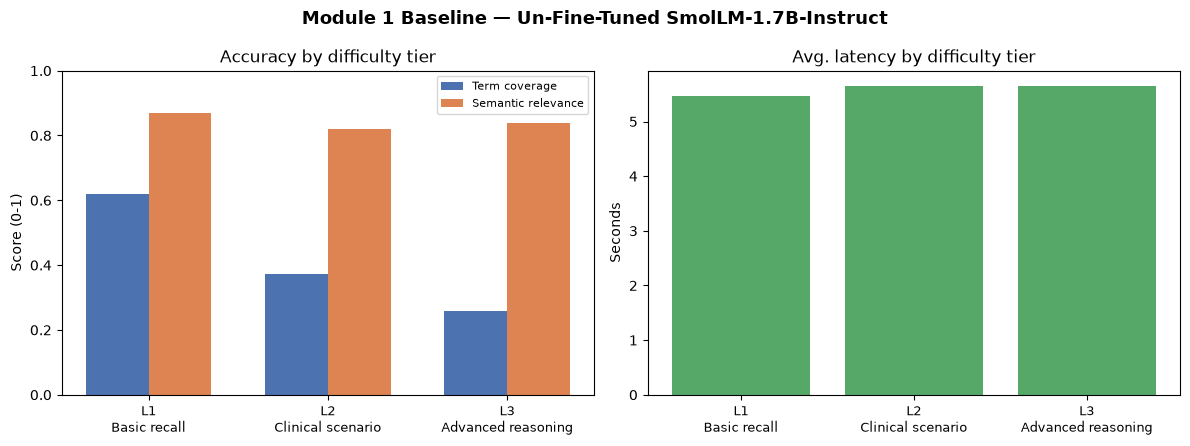

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Module 1 Baseline — Un-Fine-Tuned SmolLM-1.7B-Instruct", fontsize=13, fontweight="bold")

tiers = ["L1", "L2", "L3"]
tier_labels = ["L1\nBasic recall", "L2\nClinical scenario", "L3\nAdvanced reasoning"]

ax = axes[0]
x = np.arange(len(tiers))
width = 0.35
ax.bar(x - width/2, by_diff["term_coverage"], width, label="Term coverage", color="#4C72B0")
ax.bar(x + width/2, by_diff["semantic_relevance"], width, label="Semantic relevance", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(tier_labels, fontsize=9)
ax.set_ylim(0, 1); ax.set_ylabel("Score (0-1)")
ax.set_title("Accuracy by difficulty tier")
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.bar(tier_labels, by_diff["latency_sec"], color="#55A868")
ax2.set_ylabel("Seconds")
ax2.set_title("Avg. latency by difficulty tier")
ax2.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.show()

In [27]:
# Save results to the shared Drive folder — Module 2 will load this as the "before" picture.
module1_baseline_df.to_json(f"{RESULTS_DIR}/module1_baseline.json", orient="records", indent=2)

with open(f"{RESULTS_DIR}/module1_baseline_summary.json", "w") as f:
    json.dump({
        "model": "Module 1 — Base SmolLM-1.7B-Instruct (no fine-tuning)",
        "overall": overall.to_dict(),
        "by_difficulty": by_diff.to_dict(orient="index"),
    }, f, indent=2)

print(f"💾 Saved → {RESULTS_DIR}/module1_baseline.json")
print(f"💾 Saved → {RESULTS_DIR}/module1_baseline_summary.json")
print("\n➡️  Module 2 fine-tunes this exact model and re-runs this exact eval set to measure the lift.")

del medilearn_model
if device == "cuda":
    torch.cuda.empty_cache()
elif device == "mps":
    torch.mps.empty_cache()


💾 Saved → /Users/sudhanshusingh/Projects/DHS-SLM-Workshop/SLM_Workshop/eval/results/module1_baseline.json
💾 Saved → /Users/sudhanshusingh/Projects/DHS-SLM-Workshop/SLM_Workshop/eval/results/module1_baseline_summary.json

➡️  Module 2 fine-tunes this exact model and re-runs this exact eval set to measure the lift.


In [29]:
# import torch
# import soundfile as sf
# from transformers import pipeline
# from huggingface_hub import login
# import os
# from IPython.display import Audio

# # Login
# hf_token = os.environ.get("HF_TOKEN")
# if hf_token:
#     login(hf_token)
# else:
#     # fallback to interactive login if token is not in env
#     # login()
#     pass

# # Load pipeline
# tts = pipeline(
#     "text-to-speech",
#     model="Qwen/Qwen3-TTS-12Hz-1.7B-CustomVoice",
#     device="cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else -1,
#     torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
# )

# # Text
# text = """
# Artificial Intelligence is transforming how humans interact with technology.
# Welcome to this speech synthesis demonstration using Qwen3 TTS.
# """

# # Generate
# result = tts(text)

# # Save
# sf.write(
#     "sample.wav",
#     result["audio"],
#     result["sampling_rate"],
# )

# # Play
# Audio("sample.wav")

---
## 🧩 Part 8: Beyond Chat — Specialized SLMs (Multimodal, Speech, Code)

Everything so far has been a **general-purpose, text-in/text-out** chat SLM. But the small-model
ecosystem on Hugging Face also has purpose-built variants for other modalities and domains. In this
part we load **one of each**, all under ~2.5B parameters, all free/ungated, and all compatible with
the `transformers` version already installed in Part 0:

| Type | Model | Params | What it does |
|---|---|---|---|
| 🖼️ **Multimodal (vision+language)** | [`Qwen/Qwen2-VL-2B-Instruct`](https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct) | 2B | Reads an image *and* text together, answers questions about the image |
| 🔊 **Text-to-Speech (TTS)** | [`microsoft/speecht5_tts`](https://huggingface.co/microsoft/speecht5_tts) | ~0.1B | Converts text into spoken audio using a selectable speaker voice |
| 💻 **Code-specific** | [`Qwen/Qwen2.5-Coder-1.5B-Instruct`](https://huggingface.co/Qwen/Qwen2.5-Coder-1.5B-Instruct) | 1.5B | Instruction-tuned specifically on code — generation, completion, explanation, debugging |

**Why this matters:** picking the right *type* of small model for the job matters as much as picking
the right size. A 1.5B code-specialist will usually beat a 7B general chat model on code tasks, and a
general chat SLM has no way to "see" an image or "speak" at all — you need the right architecture family.

> ⚠️ **Runtime note:** Each model below is loaded, used, and can be released (`del model; torch.cuda.empty_cache()`)
> independently — you don't need to keep all three in memory on a T4 (16GB) at once, though it's possible
> alongside the Part 3 benchmark models if you restart the runtime first.


### 8.1 🖼️ Multimodal SLM — Qwen2-VL-2B-Instruct

[Qwen2-VL-2B-Instruct](https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct) is a **vision-language model**:
it takes an image and a text prompt together and reasons about both. Unlike the text-only SLMs in
Part 3, this model has a vision encoder in front of its language model, so it can do things like
image captioning, visual Q&A, and reading text inside an image (OCR-style).

- **License:** Apache 2.0 (no gating / approval needed on Hugging Face)
- **Requires:** `transformers>=4.45` (for the `Qwen2VLForConditionalGeneration` class) + the `qwen-vl-utils`
  helper package for image/video preprocessing
- **Memory:** ~4-5 GB in bfloat16 — fits comfortably on a T4


In [30]:
# Install multimodal-specific dependencies.
# Qwen2-VL needs transformers >= 4.45 (already satisfied if Part 0 installed a recent version)
# plus qwen-vl-utils for image/video preprocessing helpers.
!pip install -q "transformers>=4.45.0" qwen-vl-utils accelerate

print("✅ Multimodal dependencies installed!")


pyenv: version `3.13' is not installed (set by /Users/sudhanshusingh/Projects/DHS-SLM-Workshop/.python-version)
pyenv: pip: command not found

The `pip' command exists in these Python versions:
  3.12.13
  3.14.4
  miniforge3-26.3.2-0

Note: See 'pyenv help global' for tips on allowing multiple
      Python versions to be found at the same time.
✅ Multimodal dependencies installed!


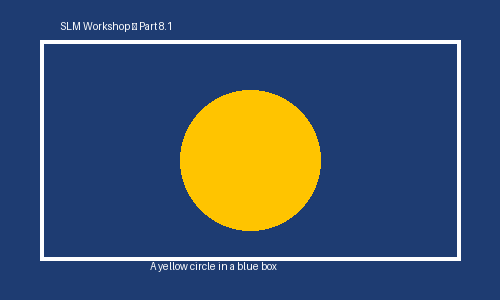

In [31]:
# Build a simple synthetic test image (no internet dependency, works in any Colab session)
from PIL import Image, ImageDraw, ImageFont

img = Image.new("RGB", (500, 300), color=(30, 60, 114))
draw = ImageDraw.Draw(img)
draw.rectangle([40, 40, 460, 260], outline=(255, 255, 255), width=4)
draw.ellipse([180, 90, 320, 230], fill=(255, 196, 0))
draw.text((60, 20), "SLM Workshop — Part 8.1", fill=(255, 255, 255))
draw.text((150, 260), "A yellow circle in a blue box", fill=(255, 255, 255))

img.save("multimodal_test.png")
img


In [3]:
# Load Qwen2-VL-2B-Instruct and ask it about the image above
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

MULTIMODAL_MODEL = "Qwen/Qwen2-VL-2B-Instruct"
print(f"🔧 Loading {MULTIMODAL_MODEL} ...")

vl_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MULTIMODAL_MODEL,
    torch_dtype=torch.bfloat16 if device in ["cuda", "mps"] else torch.float32,
    device_map="auto" if device == "cuda" else None,
)
if device == "mps":
    vl_model = vl_model.to(device)
vl_processor = AutoProcessor.from_pretrained(MULTIMODAL_MODEL)

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": "multimodal_test.png"},
            {"type": "text", "text": "Describe what shapes and colors you see in this image."},
        ],
    }
]

text_prompt = vl_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = vl_processor(
    text=[text_prompt],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
).to(vl_model.device)

with torch.no_grad():
    generated_ids = vl_model.generate(**inputs, max_new_tokens=128)

generated_trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, generated_ids)]
response = vl_processor.batch_decode(generated_trimmed, skip_special_tokens=True)[0]

print("🖼️  Model response:")
print(f"   {response}")


🔧 Loading Qwen/Qwen2-VL-2B-Instruct ...


Loading weights: 100%|██████████| 729/729 [00:00<00:00, 12465.85it/s]


🖼️  Model response:
   In the image, you can see a blue box with a white border. Inside the box, there is a yellow circle.


In [6]:
# Free the multimodal model's memory before loading the next specialized model
del vl_model
torch.cuda.empty_cache() if device == "cuda" else torch.mps.empty_cache() if device == "mps" else None
print("🧹 Multimodal model unloaded.")


🧹 Multimodal model unloaded.


### 8.2 🔊 Text-to-Speech SLM — SpeechT5 (microsoft/speecht5_tts)

[SpeechT5](https://huggingface.co/microsoft/speecht5_tts) converts text into spoken audio. It's not a
"language model" in the chat sense — it's a small (~0.1B) encoder-decoder model that predicts a
mel-spectrogram from text, then a vocoder (`speecht5_hifigan`) turns that into an audio waveform. It
also takes a **speaker embedding** vector, so the same model can speak in different voices.

- **License:** MIT
- **Requires:** `transformers` `pipeline("text-to-speech", ...)` support (built in), `datasets` for the
  sample speaker-embedding dataset, and `soundfile` to write the `.wav` file
- **Memory:** well under 1 GB — this one is comfortable even on CPU-only runtimes

> 📝 This replaces the need for the earlier `Qwen3-TTS` snippet later in the notebook, which needs Qwen's
> own `qwen_tts` package rather than the standard `transformers` pipeline — SpeechT5 works out of the box
> with the libraries already installed in Part 0.


In [7]:
# Install TTS-specific dependency (datasets + soundfile are already installed in Part 0)
!pip install -q soundfile
print("✅ TTS dependencies ready!")


pyenv: version `3.13' is not installed (set by /Users/sudhanshusingh/Projects/DHS-SLM-Workshop/.python-version)
pyenv: pip: command not found

The `pip' command exists in these Python versions:
  3.12.13
  3.14.4
  miniforge3-26.3.2-0

Note: See 'pyenv help global' for tips on allowing multiple
      Python versions to be found at the same time.
✅ TTS dependencies ready!


In [8]:
# Load SpeechT5 and synthesize speech from text
import torch
import soundfile as sf
from transformers import pipeline
from datasets import load_dataset
from IPython.display import Audio

TTS_MODEL = "microsoft/speecht5_tts"
print(f"🔧 Loading {TTS_MODEL} ...")

tts = pipeline("text-to-speech", TTS_MODEL, device="cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else -1)

# SpeechT5 needs a speaker embedding to know which voice to use.
# We pull one pre-computed example voice from a public x-vector dataset.
# NOTE: this dataset repo only ships a loading *script*, and recent versions of the
# datasets library no longer support script-based datasets. Loading the
# auto-converted parquet revision avoids the "Dataset scripts are no longer
# supported" error.
embeddings_dataset = load_dataset(
    "Matthijs/cmu-arctic-xvectors", split="validation", revision="refs/convert/parquet"
)
speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0)

tts_text = "Small language models bring powerful AI capabilities to edge and resource-constrained environments."

speech = tts(tts_text, forward_params={"speaker_embeddings": speaker_embedding})

sf.write("tts_sample.wav", speech["audio"], samplerate=speech["sampling_rate"])
print(f"🔊 Generated {len(speech['audio']) / speech['sampling_rate']:.1f}s of audio → tts_sample.wav")

Audio("tts_sample.wav")

🔧 Loading microsoft/speecht5_tts ...


Loading weights: 100%|██████████| 396/396 [00:00<00:00, 63440.83it/s]
[transformers] SpeechT5ForTextToSpeech LOAD REPORT from: microsoft/speecht5_tts
Key                                         | Status     |  | 
--------------------------------------------+------------+--+-
speecht5.decoder.prenet.encode_positions.pe | UNEXPECTED |  | 
speecht5.encoder.prenet.encode_positions.pe | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] You are using a model of type `hifigan` to instantiate a model of type `speecht5_hifigan`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
Loading weights: 100%|██████████| 158/158 [00:00<00:00, 37406.87it/s]
Generati

🔊 Generated 6.7s of audio → tts_sample.wav


In [9]:
# Free the TTS pipeline's memory before loading the next specialized model
del tts
torch.cuda.empty_cache() if device == "cuda" else torch.mps.empty_cache() if device == "mps" else None
print("🧹 TTS model unloaded.")


🧹 TTS model unloaded.


### 8.3 💻 Code-Specific SLM — Qwen2.5-Coder-1.5B-Instruct

[Qwen2.5-Coder-1.5B-Instruct](https://huggingface.co/Qwen/Qwen2.5-Coder-1.5B-Instruct) is from the same
family as the Qwen2.5-1.5B-Instruct model benchmarked in Part 3 — but pre-trained and instruction-tuned
specifically on **code**: generation, completion, explanation, debugging, and repo-level context. At the
same 1.5B parameter size, it consistently outperforms general-purpose chat SLMs on coding tasks.

- **License:** Apache 2.0
- **Requires:** nothing beyond what's already installed — same `AutoModelForCausalLM` / `AutoTokenizer`
  pattern used throughout this notebook
- **Memory:** ~3 GB in fp16


In [10]:
# Load Qwen2.5-Coder-1.5B-Instruct — same loading pattern as the Part 3 benchmark models
from transformers import AutoTokenizer, AutoModelForCausalLM

CODE_MODEL = "Qwen/Qwen2.5-Coder-1.5B-Instruct"
print(f"🔧 Loading {CODE_MODEL} ...")

code_tokenizer = AutoTokenizer.from_pretrained(CODE_MODEL)
code_model = AutoModelForCausalLM.from_pretrained(
    CODE_MODEL,
    dtype=torch.float16 if device in ["cuda", "mps"] else torch.float32,
).to(device)
code_model.eval()

code_prompt = "Write a Python function that returns the nth Fibonacci number using memoization. Include a docstring."

messages = [{"role": "user", "content": code_prompt}]
# apply_chat_template(..., tokenize=True, return_tensors="pt") returns a BatchEncoding
# (a dict with input_ids/attention_mask), not a bare tensor — so it has no .shape
# attribute. Unpack it into generate() with ** and pull input_ids out explicitly
# when computing the prompt length for decoding.
code_inputs = code_tokenizer.apply_chat_template(
    messages, tokenize=True, add_generation_prompt=True, return_tensors="pt", return_dict=True
).to(device)

with torch.no_grad():
    code_output = code_model.generate(
        **code_inputs,
        max_new_tokens=250,
        do_sample=False,
        pad_token_id=code_tokenizer.eos_token_id,
    )

prompt_len = code_inputs["input_ids"].shape[-1]
code_response = code_tokenizer.decode(code_output[0][prompt_len:], skip_special_tokens=True)
print("💻 Generated code:\n")
print(code_response)


🔧 Loading Qwen/Qwen2.5-Coder-1.5B-Instruct ...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 338/338 [00:02<00:00, 140.18it/s]


💻 Generated code:

```python
def fibonacci(n, memo={}):
    """
    Calculate the nth Fibonacci number using memoization.
    
    Args:
    n (int): The position in the Fibonacci sequence to calculate.
    memo (dict): A dictionary to store previously calculated Fibonacci numbers for efficiency.
    
    Returns:
    int: The nth Fibonacci number.
    """
    if n <= 1:
        return n
    elif n not in memo:
        memo[n] = fibonacci(n-1, memo) + fibonacci(n-2, memo)
    return memo[n]

# Check function with provided data points
def check_fibonacci():
    test_cases = [(0, 0), (1, 1), (2, 1), (3, 2), (4, 3), (5, 5)]
    for n, expected in test_cases:
        assert fibonacci(n) == expected, f"Failed on {n}"
    print("All test cases passed!")

check_fibonacci()
```

This code snippet defines a function `fibonacci` that calculates the nth Fibonacci number using memoization. Memoization is a technique where you store the results of expensive function calls and return the cached resu

In [11]:
# Free the code model's memory
del code_model
torch.cuda.empty_cache() if device == "cuda" else torch.mps.empty_cache() if device == "mps" else None
print("🧹 Code model unloaded.")


🧹 Code model unloaded.


### 8.4 Takeaways: Choosing the Right SLM Type

| If your task is... | Reach for... | Not a general chat SLM because... |
|---|---|---|
| Understanding/describing images, visual Q&A, OCR-in-image | A **vision-language** model (e.g. Qwen2-VL) | Text-only chat SLMs have no vision encoder — they can't process pixels at all |
| Generating spoken audio output | A **TTS** model (e.g. SpeechT5) | Chat SLMs output text tokens, not audio waveforms — different output space entirely |
| Writing/debugging/explaining code | A **code-specific** model (e.g. Qwen2.5-Coder) | Same size class, but code-focused pre-training data means noticeably better code quality |

Just like in Part 3, always benchmark the specialized model **on your actual use case** rather than
trusting general leaderboard rankings alone — the same "task-model fit" principle from Part 6 applies here too.
